# Evaluation S1 ↔ S2 — Herbe à Poux YOLOv11n-cls

**Objectif.** Tester la généralisation croisée des deux modèles sur les données de l'autre scénario :

- **M1 → D2** : `1er_yolo11n-cls.pt` (entraîné sur terrain Sherbrooke) évalué sur toutes les photos du **Scénario 2** (iNaturalist global).
- **M2 → D1** : `2e_yolo11n-cls.pt` (entraîné sur iNaturalist global) évalué sur toutes les photos du **Scénario 1** (terrain Sherbrooke).

**Données évaluées.** On utilise directement les dossiers bruts de chaque scénario :
- `Photos_Positifs/` → vérité terrain = `ambrosia`
- `Photos_Negatifs/` → vérité terrain = `non_ambrosia`

**Validité méthodologique.** Seules M1→D2 et M2→D1 sont évaluées. M1→D1 et M2→D2 seraient contaminées par les données d'entraînement (data leakage) puisque les `Photos_Positifs`/`Photos_Negatifs` d'un scénario contiennent les images train+val+test de son propre modèle.


## 📦 Installation

In [ ]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.9 MB/s eta 0:00:00


> Si c'est la **première installation** de la session, redémarre le runtime puis relance à partir de la cellule suivante.

## ⚙️ Configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    roc_auc_score, cohen_kappa_score,
)
from ultralytics import YOLO
from tqdm.auto import tqdm
import torch

GDRIVE = '/content/drive/MyDrive'
S1_DIR = os.path.join(GDRIVE, '1er scénario_herbe_a_poux_yolo11ncls')
S2_DIR = os.path.join(GDRIVE, '2e scénario_herbe_a_poux_yolo11ncls')

# Modèles
S1_MODEL = os.path.join(S1_DIR, 'Modeles', '1er_yolo11n-cls.pt')
S2_MODEL = os.path.join(S2_DIR, 'Modeles', '2e_yolo11n-cls.pt')

# Données brutes — chaque scénario a Photos_Positifs + Photos_Negatifs
D1_POS = os.path.join(S1_DIR, 'Photos_Positifs')
D1_NEG = os.path.join(S1_DIR, 'Photos_Negatifs')
D2_POS = os.path.join(S2_DIR, 'Photos_Positifs')
D2_NEG = os.path.join(S2_DIR, 'Photos_Negatifs')

OUT_DIR = os.path.join(GDRIVE, 'Cross_Evaluation_S1_S2')
os.makedirs(OUT_DIR, exist_ok=True)

IMG_SIZE   = 224
BATCH_SIZE = 256
RUN_TAG    = datetime.now().strftime('%Y%m%d_%H%M%S')

print('Vérification des chemins :')
for label, p in [
    ('Modèle S1 ', S1_MODEL),
    ('Modèle S2 ', S2_MODEL),
    ('D1 Pos    ', D1_POS),
    ('D1 Neg    ', D1_NEG),
    ('D2 Pos    ', D2_POS),
    ('D2 Neg    ', D2_NEG),
]:
    status = '✓' if os.path.exists(p) else '✗ MANQUANT'
    print(f'  {status}  {label} : {p}')

print(f'\nRun    : {RUN_TAG}')
print(f'Sortie : {OUT_DIR}')


Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Vérification des chemins :
  ✓  Modèle S1  : /content/drive/MyDrive/1er scénario_herbe_a_poux_yolo11ncls/Modeles/1er_yolo11n-cls.pt
  ✓  Modèle S2  : /content/drive/MyDrive/2e scénario_herbe_a_poux_yolo11ncls/Modeles/2e_yolo11n-cls.pt
  ✓  D1 Pos     : /content/drive/MyDrive/1er scénario_herbe_a_poux_yolo11ncls/Photos_Positifs
  ✓  D1 Neg     : /content/drive/MyDrive/1er scénario_herbe_a_poux_yolo11ncls/Photos_Negatifs
  ✓  D2 Pos     : /content/drive/MyDrive/2e scénario_herbe_a_poux_yolo11ncls/Photos_Positifs
  ✓  D2 Neg     : /content/drive/MyDrive/2e scénario_herbe_a_poux_yolo11ncls/Photos_Negatifs

Run    : 20260413_061811
Sortie : /content/drive/MyDr

## 🧩 Fonction d'évaluation

L'évaluation prend en entrée les deux dossiers bruts (positifs + négatifs) et les mappe vers les labels du modèle. Les prédictions YOLO utilisent toujours les noms de classes d'**entraînement** (`ambrosia` / `non_ambrosia`), donc on mappe :

- `Photos_Positifs/` → index de `ambrosia` dans `model.names`
- `Photos_Negatifs/` → index de `non_ambrosia` dans `model.names`

Cela garantit que le mapping reste correct même si les classes du modèle sont dans un ordre différent.


In [ ]:
IMG_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def lister_images(dossier: str) -> list:
    """Liste récursive et triée des images dans un dossier."""
    if not os.path.exists(dossier):
        return []
    return sorted([
        str(p) for p in Path(dossier).rglob('*')
        if p.suffix.lower() in IMG_EXT
    ])


def evaluer(model_path: str, pos_dir: str, neg_dir: str, nom: str) -> dict:
    print(f'\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    print(f'  {nom}')
    print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    print(f'  Modèle : {Path(model_path).name}')
    print(f'  Pos    : {pos_dir}')
    print(f'  Neg    : {neg_dir}')

    model = YOLO(model_path)
    class_names = [model.names[i] for i in sorted(model.names.keys())]
    print(f'  Classes modèle : {class_names}')

    # Index robustes pour ambrosia / non_ambrosia
    idx_ambr = next(
        (i for i, n in enumerate(class_names) if n.lower().startswith('ambrosia')),
        None
    )
    idx_neg = next(
        (i for i, n in enumerate(class_names) if 'non' in n.lower() or 'neg' in n.lower()),
        None
    )
    if idx_ambr is None or idx_neg is None:
        raise ValueError(f'Impossible de mapper les classes : {class_names}')

    # Collecte des images avec vérité terrain depuis le NOM du dossier
    pos_imgs = lister_images(pos_dir)
    neg_imgs = lister_images(neg_dir)
    print(f'  Images Pos : {len(pos_imgs)}')
    print(f'  Images Neg : {len(neg_imgs)}')

    paths  = pos_imgs + neg_imgs
    y_true = np.array([idx_ambr] * len(pos_imgs) + [idx_neg] * len(neg_imgs))

    if len(paths) == 0:
        raise ValueError(f'Aucune image trouvée dans {pos_dir} ou {neg_dir}')

    # ── Phase 1 : pré-copie des images Drive → disque local Colab ──
    # Drive est lent en lecture aléatoire ; copier d'abord est beaucoup plus rapide
    # et donne une barre de progression visible.
    import tempfile, shutil
    local_dir = tempfile.mkdtemp(prefix='cross_eval_')
    local_paths = []
    pbar_copy = tqdm(
        paths,
        desc=f'  Copie Drive→local [{nom}]',
        unit='img',
        ncols=100,
        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]',
    )
    for i, src_path in enumerate(pbar_copy):
        ext = Path(src_path).suffix.lower()
        dst = os.path.join(local_dir, f'{i:06d}{ext}')
        shutil.copy(src_path, dst)
        local_paths.append(dst)
    pbar_copy.close()

    # ── Phase 2 : inférence batchée sur les fichiers locaux ──
    n_classes = len(class_names)
    y_pred    = np.zeros(len(paths), dtype=int)
    y_scores  = np.zeros((len(paths), n_classes), dtype=float)

    device = 0 if torch.cuda.is_available() else 'cpu'
    pbar = tqdm(
        total=len(local_paths),
        desc=f'  Inférence   [{nom}]',
        unit='img',
        ncols=100,
        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]',
    )
    use_half = torch.cuda.is_available()
    with torch.inference_mode():
        for start in range(0, len(local_paths), BATCH_SIZE):
            end = min(start + BATCH_SIZE, len(local_paths))
            results = model.predict(
                local_paths[start:end],
                imgsz=IMG_SIZE,
                verbose=False,
                device=device,
                half=use_half,   # FP16 sur GPU — ~2-3× plus rapide sur A100
            )
            for k, r in enumerate(results):
                probs = r.probs.data.cpu().numpy()
                y_scores[start + k] = probs
                y_pred[start + k]   = int(probs.argmax())
            pbar.update(end - start)
            pbar.refresh()
    pbar.close()

    # Nettoyage du dossier temporaire local
    shutil.rmtree(local_dir, ignore_errors=True)

    # Métriques
    acc   = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    try:
        auc = roc_auc_score(
            (y_true == idx_ambr).astype(int),
            y_scores[:, idx_ambr]
        )
    except Exception as e:
        print(f'  ROC-AUC indisponible : {e}')
        auc = None
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))

    print(f'\n  Accuracy  : {acc*100:6.2f}%')
    print(f'  F1-Macro  : {f1:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  Kappa     : {kappa:.4f}')
    if auc is not None:
        print(f'  ROC-AUC   : {auc:.4f}')
    print()
    print(classification_report(
        y_true, y_pred, target_names=class_names, digits=4, zero_division=0
    ))

    return {
        'nom'        : nom,
        'n_images'   : len(paths),
        'n_pos'      : len(pos_imgs),
        'n_neg'      : len(neg_imgs),
        'class_names': class_names,
        'accuracy'   : float(acc),
        'f1_macro'   : float(f1),
        'precision'  : float(prec),
        'recall'     : float(rec),
        'kappa'      : float(kappa),
        'auc'        : float(auc) if auc is not None else None,
        'confusion'  : cm.tolist(),
    }


## 🧪 Exécution des cross-évaluations

In [ ]:
# M1 (terrain Sherbrooke) testé sur toutes les photos du Scénario 2
res_M1_D2 = evaluer(S1_MODEL, D2_POS, D2_NEG, 'M1 → D2  (S1 sur données S2)')

# M2 (iNaturalist global) testé sur toutes les photos du Scénario 1
res_M2_D1 = evaluer(S2_MODEL, D1_POS, D1_NEG, 'M2 → D1  (S2 sur données S1)')



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  M1 → D2  (S1 sur données S2)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Modèle : 1er_yolo11n-cls.pt
  Pos    : /content/drive/MyDrive/2e scénario_herbe_a_poux_yolo11ncls/Photos_Positifs
  Neg    : /content/drive/MyDrive/2e scénario_herbe_a_poux_yolo11ncls/Photos_Negatifs
  Classes modèle : ['ambrosia', 'non_ambrosia']
  Images Pos : 5454
  Images Neg : 5458


  Copie Drive→local [M1 → D2  (S1 sur données S2)]:   0%|                | 0/10912 [00:00<?, ?img/s]

  Inférence   [M1 → D2  (S1 sur données S2)]:   0%|                      | 0/10912 [00:00<?, ?img/s]


  Accuracy  :  89.54%
  F1-Macro  : 0.8954
  Precision : 0.8958
  Recall    : 0.8954
  Kappa     : 0.7909
  ROC-AUC   : 0.9597

              precision    recall  f1-score   support

    ambrosia     0.8838    0.9105    0.8970      5454
non_ambrosia     0.9078    0.8804    0.8939      5458

    accuracy                         0.8954     10912
   macro avg     0.8958    0.8954    0.8954     10912
weighted avg     0.8958    0.8954    0.8954     10912


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  M2 → D1  (S2 sur données S1)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Modèle : 2e_yolo11n-cls.pt
  Pos    : /content/drive/MyDrive/1er scénario_herbe_a_poux_yolo11ncls/Photos_Positifs
  Neg    : /content/drive/MyDrive/1er scénario_herbe_a_poux_yolo11ncls/Photos_Negatifs
  Classes modèle : ['ambrosia', 'non_ambrosia']
  Images Pos : 3580
  Images Neg : 3577


  Copie Drive→local [M2 → D1  (S2 sur données S1)]:   0%|                 | 0/7157 [00:00<?, ?img/s]

  Inférence   [M2 → D1  (S2 sur données S1)]:   0%|                       | 0/7157 [00:00<?, ?img/s]


  Accuracy  :  94.19%
  F1-Macro  : 0.9419
  Precision : 0.9419
  Recall    : 0.9419
  Kappa     : 0.8837
  ROC-AUC   : 0.9848

              precision    recall  f1-score   support

    ambrosia     0.9402    0.9439    0.9420      3580
non_ambrosia     0.9436    0.9399    0.9417      3577

    accuracy                         0.9419      7157
   macro avg     0.9419    0.9419    0.9419      7157
weighted avg     0.9419    0.9419    0.9419      7157



## 📊 Tableau comparatif

In [ ]:
resultats = [res_M1_D2, res_M2_D1]

df = pd.DataFrame([{
    'Évaluation': r['nom'],
    'N images'  : r['n_images'],
    'N Pos'     : r['n_pos'],
    'N Neg'     : r['n_neg'],
    'Accuracy'  : f'{r["accuracy"]*100:.2f}%',
    'F1-Macro'  : f'{r["f1_macro"]:.4f}',
    'Precision' : f'{r["precision"]:.4f}',
    'Recall'    : f'{r["recall"]:.4f}',
    'Kappa'     : f'{r["kappa"]:.4f}',
    'ROC-AUC'   : f'{r["auc"]:.4f}' if r['auc'] is not None else 'n/a',
} for r in resultats])
print(df.to_string(index=False))

df.to_csv(os.path.join(OUT_DIR, f'resume_cross_eval_{RUN_TAG}.csv'), index=False)


NameError: name 'res_M1_D2' is not defined

## 📈 Visualisations

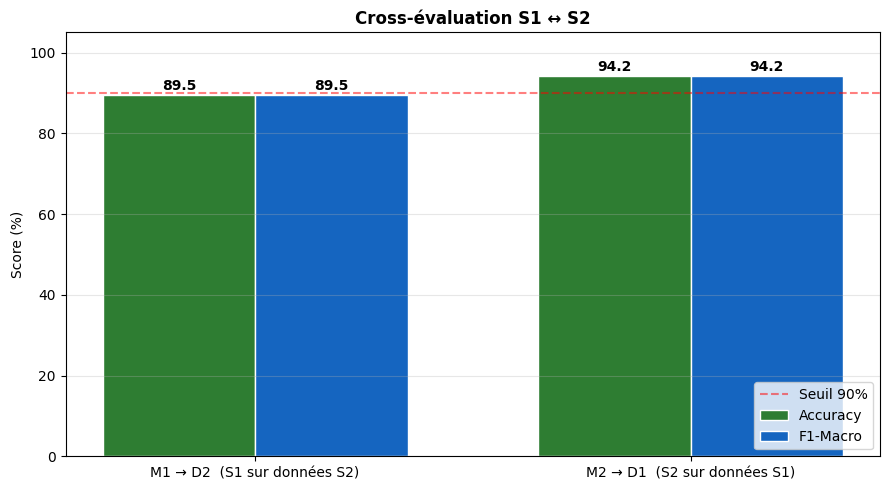

In [ ]:
# Barres comparatives Accuracy / F1
fig, ax = plt.subplots(figsize=(9, 5))
noms = [r['nom'] for r in resultats]
accs = [r['accuracy']*100 for r in resultats]
f1s  = [r['f1_macro']*100 for r in resultats]

x = np.arange(len(noms))
w = 0.35
b1 = ax.bar(x - w/2, accs, w, label='Accuracy', color='#2E7D32', edgecolor='white')
b2 = ax.bar(x + w/2, f1s,  w, label='F1-Macro', color='#1565C0', edgecolor='white')

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.axhline(90, color='red', linestyle='--', alpha=0.5, label='Seuil 90%')
ax.set_xticks(x)
ax.set_xticklabels(noms, fontsize=10)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 105)
ax.set_title('Cross-évaluation S1 ↔ S2', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'barres_{RUN_TAG}.png'), dpi=150)
plt.show()


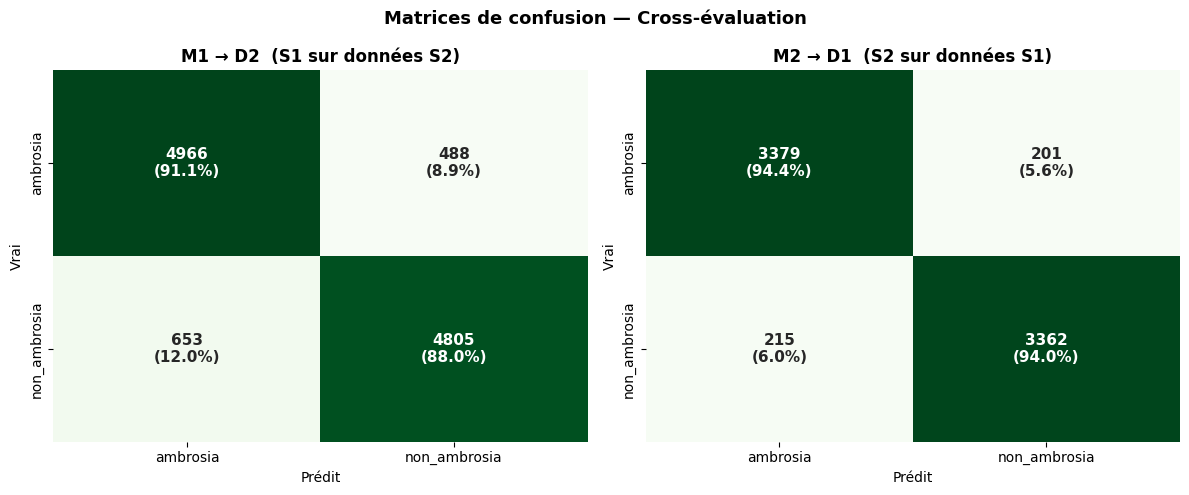

In [ ]:
# Matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, res in zip(axes, resultats):
    cm = np.array(res['confusion'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = [[f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)'
              for j in range(cm.shape[1])] for i in range(cm.shape[0])]
    sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Greens',
                xticklabels=res['class_names'], yticklabels=res['class_names'],
                cbar=False, ax=ax, annot_kws={'size': 11, 'weight': 'bold'})
    ax.set_title(res['nom'], fontweight='bold')
    ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')

plt.suptitle('Matrices de confusion — Cross-évaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'confusion_{RUN_TAG}.png'), dpi=150)
plt.show()


## 📊 Distribution des prédictions correctes / incorrectes par classe

Pour chaque cross-évaluation et chaque classe (`ambrosia`, `non_ambrosia`), on compte combien d'images sont correctement classifiées vs mal classifiées. C'est une lecture complémentaire des matrices de confusion : les barres empilées mettent en évidence si un modèle échoue surtout sur la classe positive ou négative.


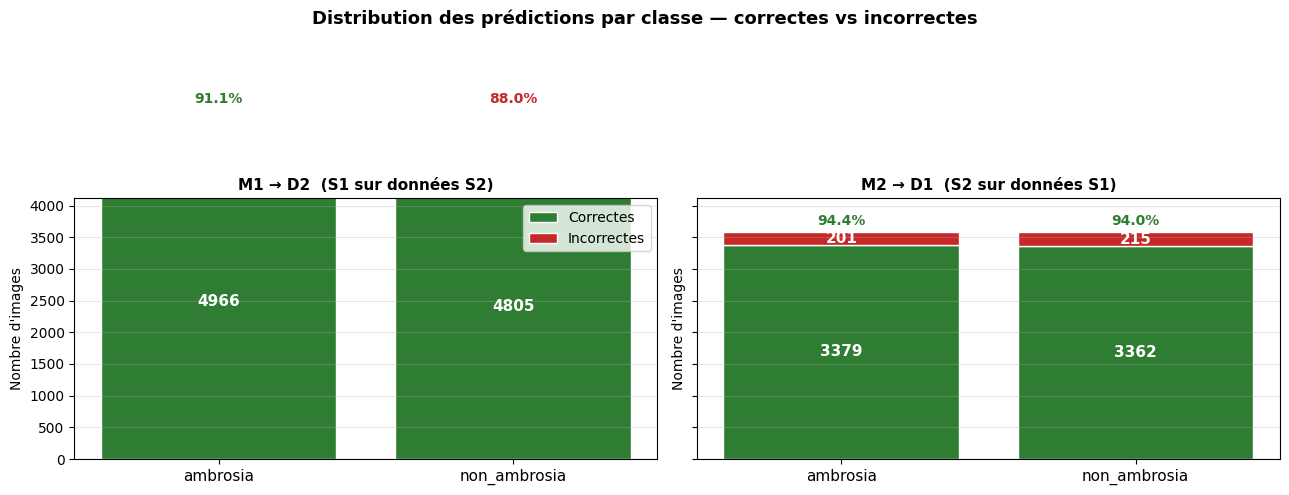



M1 → D2  (S1 sur données S2)
  ambrosia        :  4966 correctes /   488 incorrectes  ( 91.1% réussite sur 5454 images)
  non_ambrosia    :  4805 correctes /   653 incorrectes  ( 88.0% réussite sur 5458 images)

M2 → D1  (S2 sur données S1)
  ambrosia        :  3379 correctes /   201 incorrectes  ( 94.4% réussite sur 3580 images)
  non_ambrosia    :  3362 correctes /   215 incorrectes  ( 94.0% réussite sur 3577 images)


In [ ]:
# Distribution correct/incorrect par classe, pour chaque cross-évaluation
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, res in zip(axes, resultats):
    cm = np.array(res['confusion'])
    class_names = res['class_names']
    corrects   = np.diag(cm)                     # vrais positifs + vrais négatifs par classe
    incorrects = cm.sum(axis=1) - corrects       # erreurs par classe (lignes = vrai label)

    x = np.arange(len(class_names))
    b_ok = ax.bar(x, corrects,   color='#2E7D32', edgecolor='white',
                  label='Correctes')
    b_ko = ax.bar(x, incorrects, bottom=corrects, color='#C62828', edgecolor='white',
                  label='Incorrectes')

    # Annotations : nombres + pourcentage de réussite par classe
    totals = corrects + incorrects
    for i, (ok, ko, tot) in enumerate(zip(corrects, incorrects, totals)):
        pct = (ok / tot * 100) if tot > 0 else 0
        if ok > 0:
            ax.text(i, ok / 2, f'{int(ok)}', ha='center', va='center',
                    color='white', fontweight='bold', fontsize=11)
        if ko > 0:
            ax.text(i, ok + ko / 2, f'{int(ko)}', ha='center', va='center',
                    color='white', fontweight='bold', fontsize=11)
        ax.text(i, tot + max(totals) * 0.02, f'{pct:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=10,
                color='#2E7D32' if pct >= 90 else '#C62828')

    ax.set_xticks(x)
    ax.set_xticklabels(class_names, fontsize=11)
    ax.set_title(res['nom'], fontweight='bold', fontsize=11)
    ax.set_ylabel('Nombre d\'images')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(totals) * 1.15)

axes[0].legend(loc='upper right', fontsize=10)
plt.suptitle('Distribution des prédictions par classe — correctes vs incorrectes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'distribution_{RUN_TAG}.png'), dpi=150)
plt.show()

# Tableau récapitulatif des comptes
print()
for res in resultats:
    cm = np.array(res['confusion'])
    print(f'\n{res["nom"]}')
    for i, cls in enumerate(res['class_names']):
        ok  = int(np.diag(cm)[i])
        tot = int(cm.sum(axis=1)[i])
        ko  = tot - ok
        pct = ok / tot * 100 if tot > 0 else 0
        print(f'  {cls:<15} : {ok:5d} correctes / {ko:5d} incorrectes  '
              f'({pct:5.1f}% réussite sur {tot} images)')


## 💾 Sauvegarde JSON

In [ ]:
resume = {
    'run_tag'   : RUN_TAG,
    'img_size'  : IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'modeles'   : {'S1': S1_MODEL, 'S2': S2_MODEL},
    'donnees'   : {
        'D1_pos': D1_POS, 'D1_neg': D1_NEG,
        'D2_pos': D2_POS, 'D2_neg': D2_NEG,
    },
    'resultats' : {'M1_D2': res_M1_D2, 'M2_D1': res_M2_D1},
}

out_json = os.path.join(OUT_DIR, f'cross_eval_{RUN_TAG}.json')
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(resume, f, indent=2, ensure_ascii=False)
print(f'✓ Résumé JSON : {out_json}')


✓ Résumé JSON : /content/drive/MyDrive/Cross_Evaluation_S1_S2/cross_eval_20260413_061811.json


## ✅ Vérification de la sauvegarde sur Drive

Bloc ajouté pour diagnostiquer les problèmes de sauvegarde : liste le contenu réel du dossier de sortie, affiche la taille de chaque fichier, et force le flush du cache Drive pour que les fichiers apparaissent immédiatement dans l'interface web.


In [ ]:
# Vérification : lister tout ce qui a été réellement écrit dans OUT_DIR
import os, time

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  Contenu du dossier de sortie')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  {OUT_DIR}')
print()

if not os.path.exists(OUT_DIR):
    print('  ✗ Le dossier n\'existe pas !')
else:
    fichiers = sorted(os.listdir(OUT_DIR))
    if not fichiers:
        print('  ✗ Dossier vide')
    else:
        total_ko = 0
        for f in fichiers:
            chemin = os.path.join(OUT_DIR, f)
            taille = os.path.getsize(chemin)
            total_ko += taille / 1024
            mtime = time.strftime('%H:%M:%S', time.localtime(os.path.getmtime(chemin)))
            print(f'  ✓ {f:<50} {taille/1024:>8.1f} KB  (écrit à {mtime})')
        print(f'\n  Total : {len(fichiers)} fichier(s) — {total_ko:.1f} KB')

# Force la synchronisation Drive pour que les fichiers apparaissent dans l\'interface web
print('\n  Flush Drive en cours...')
try:
    from google.colab import drive
    drive.flush_and_unmount()
    time.sleep(2)
    drive.mount('/content/drive', force_remount=False)
    print('  ✓ Drive synchronisé — les fichiers devraient maintenant être visibles.')
    print(f'\n  Ouvre manuellement : https://drive.google.com/drive/my-drive')
    print(f'  puis cherche le dossier : {os.path.basename(OUT_DIR)}')
except Exception as e:
    print(f'  ⚠ Flush échoué : {e}')
    print('  Les fichiers sont écrits mais peuvent prendre quelques minutes à apparaître.')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Contenu du dossier de sortie
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  /content/drive/MyDrive/Cross_Evaluation_S1_S2

  ✓ barres_20260413_061811.png                             40.5 KB  (écrit à 09:04:50)
  ✓ confusion_20260413_061811.png                          75.2 KB  (écrit à 09:04:51)
  ✓ cross_eval_20260413_061811.json                         1.8 KB  (écrit à 09:04:52)
  ✓ distribution_20260413_061811.png                       78.4 KB  (écrit à 09:04:51)
  ✓ resume_cross_eval_20260413_061811.csv                   0.3 KB  (écrit à 09:04:50)

  Total : 5 fichier(s) — 196.1 KB

  Flush Drive en cours...
Mounted at /content/drive
  ✓ Drive synchronisé — les fichiers devraient maintenant être visibles.

  Ouvre manuellement : https://drive.google.com/drive/my-drive
  puis cherche le dossier : Cross_Evaluation_S1_S2
